# Initial Load and Clean Data Frame

In [1]:
import ast
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"C:\Users\endresju\OneDrive - Jochen Schweizer mydays Holding GmbH\S_Unterlagen und Dokumente\02_Online lernen\Luke Barousse\Python for Data Analytics\data_jobs.csv")

df['job_posted_date'] = pd.to_datetime(df.job_posted_date)
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [2]:
df_DA_US = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States')].copy()

df_DA_US = df_DA_US.dropna(subset=['salary_year_avg'])

df_DA_US.sample(10)

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
532069,Data Analyst,Data Analyst,"Washington, DC",via Indeed,Full-time,False,"New York, United States",2023-08-23 19:00:27,False,True,United States,year,118500.000000,NaN,Marathon TS,"[oracle, aws, databricks, power bi, tableau, q...","{'analyst_tools': ['power bi', 'tableau', 'qli..."
399702,Data Analyst,Data Analyst,"El Segundo, CA",via LinkedIn,Contractor,False,"California, United States",2023-02-01 18:01:02,False,True,United States,year,77500.000000,NaN,Modis,"[sql, python, r, go, tableau, looker]","{'analyst_tools': ['tableau', 'looker'], 'prog..."
540835,Data Analyst,Data Analyst,"Chicago, IL",via Ai-Jobs.net,Full-time,False,"Illinois, United States",2023-01-02 19:01:29,False,True,United States,year,111202.000000,NaN,Clarkston Consulting,"[power bi, tableau]","{'analyst_tools': ['power bi', 'tableau']}"
586738,Data Analyst,"Research Administration Data Analyst (6206U), ...","Berkeley, CA",via Indeed,Full-time,False,"California, United States",2023-12-09 09:00:28,False,True,United States,year,91700.000000,NaN,University of California Berkeley,"[spreadsheet, word]","{'analyst_tools': ['spreadsheet', 'word']}"
540749,Data Analyst,Data Analyst,"Tallahassee, FL",via Dice.com,Contractor,False,Georgia,2023-12-05 19:38:47,False,False,United States,year,65000.000000,NaN,AaraTechnologies Inc,"[sql, r, python, excel, tableau, power bi]","{'analyst_tools': ['excel', 'tableau', 'power ..."
186155,Data Analyst,"Data Analyst, Product Strategy and Operations","New York, NY",via LinkedIn,Full-time,False,"New York, United States",2023-01-04 15:00:16,True,True,United States,year,157000.000000,NaN,ByteDance,"[sql, python, r, perl, matlab, sas, sas, panda...","{'analyst_tools': ['sas', 'tableau', 'spss'], ..."
135732,Data Analyst,Managed Care & Revenue Cycle Data Analyst,"Janesville, WI",via Get.It,Full-time,False,"Illinois, United States",2023-12-10 08:01:08,False,True,United States,year,84000.000000,NaN,Get It Recruit - Information Technology,"[sql, vba, excel]","{'analyst_tools': ['excel'], 'programming': ['..."
195512,Data Analyst,Data Analyst,"Bradenton, FL",via Indeed,Full-time,False,"Florida, United States",2023-04-26 15:03:22,False,True,United States,year,45055.640625,NaN,Human Resources,"[sql, tableau, power bi]","{'analyst_tools': ['tableau', 'power bi'], 'pr..."
687598,Data Analyst,"Data Analyst, Clinical Informatics","Chicago, IL",via Ai-Jobs.net,Full-time,False,"Illinois, United States",2023-07-28 10:01:42,True,False,United States,year,111175.000000,NaN,Tempus,"[sql, r, python, excel, sheets, spreadsheet]","{'analyst_tools': ['excel', 'sheets', 'spreads..."
243958,Data Analyst,Healthcare Analytics Manager - Remote,"Dallas, TX",via WAVY Jobs,Full-time,False,"Texas, United States",2023-07-26 07:01:36,False,True,United States,year,135000.000000,NaN,Clarify Health Solutions,"[sql, python, r, excel]","{'analyst_tools': ['excel'], 'programming': ['..."


In [3]:
df_DA_US['job_posted_month_no'] = df_DA_US['job_posted_date'].dt.month

In [4]:
df_DA_US_explode = df_DA_US.explode('job_skills')

In [5]:
df_DA_US_pivot = df_DA_US_explode.pivot_table(index='job_posted_month_no', columns='job_skills', aggfunc='size', fill_value=0)

df_DA_US_pivot.loc['Total'] = df_DA_US_pivot.sum()

df_DA_US_pivot = df_DA_US_pivot[df_DA_US_pivot.loc['Total'].sort_values(ascending=False).index]

df_DA_US_pivot = df_DA_US_pivot.drop('Total')

df_DA_US_pivot

job_skills,sql,excel,python,tableau,sas,r,power bi,powerpoint,word,sql server,...,typescript,theano,erlang,selenium,solidity,couchbase,chainer,chef,cordova,node.js
job_posted_month_no,,,,,,,,,,,,,,,,,,,,,
1,256,197,137,138,86,88,88,60,43,39,...,0,0,0,0,0,0,0,0,0,0
2,212,145,114,108,76,72,80,35,28,28,...,0,0,0,0,0,0,0,1,0,0
3,224,165,130,114,68,79,73,36,34,20,...,0,0,0,0,0,0,0,0,0,0
4,210,159,112,106,92,76,72,33,33,29,...,0,0,0,0,0,0,0,0,0,0
5,217,169,114,110,70,69,67,35,41,34,...,0,0,0,0,0,0,0,0,1,0
6,259,177,154,146,96,91,97,53,61,21,...,0,0,0,0,0,1,0,0,0,0
7,256,159,140,131,88,83,56,45,40,24,...,0,0,0,1,0,0,0,0,0,0
8,261,169,162,152,110,105,88,45,44,28,...,0,0,0,0,0,0,0,0,0,0
9,149,114,82,94,64,51,47,26,27,12,...,0,0,0,0,0,0,0,0,0,1


<Axes: xlabel='job_posted_month_no'>

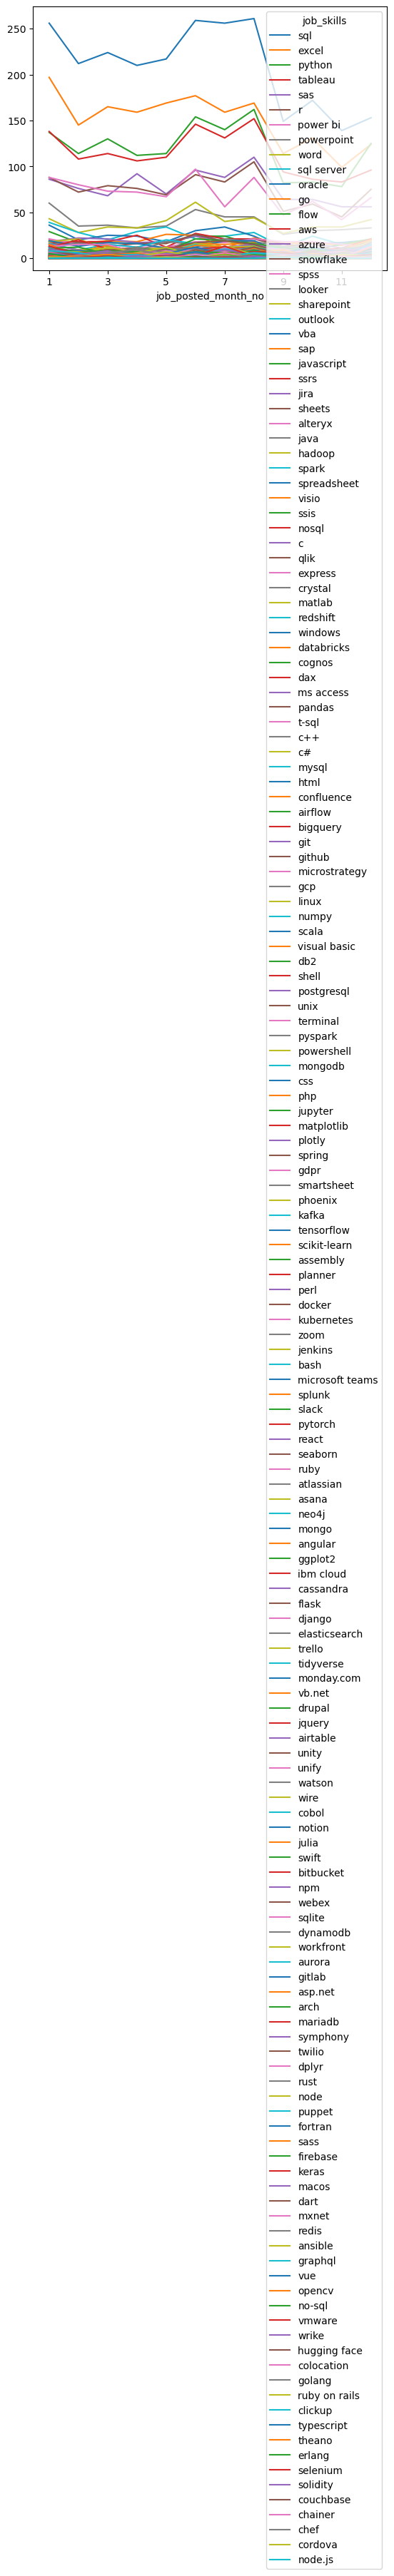

In [6]:
df_DA_US_pivot.plot(kind='line')

In [7]:
DA_totals = df_DA_US.groupby('job_posted_month_no').size()

In [8]:
df_DA_US_percent = df_DA_US_pivot.div(DA_totals/100, axis=0)

df_DA_US_percent

job_skills,sql,excel,python,tableau,sas,r,power bi,powerpoint,word,sql server,...,typescript,theano,erlang,selenium,solidity,couchbase,chainer,chef,cordova,node.js
job_posted_month_no,,,,,,,,,,,,,,,,,,,,,
1,56.140351,43.201754,30.043860,30.263158,18.859649,19.298246,19.298246,13.157895,9.429825,8.552632,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,62.170088,42.521994,33.431085,31.671554,22.287390,21.114370,23.460411,10.263930,8.211144,8.211144,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.293255,0.000000,0.000000
3,60.540541,44.594595,35.135135,30.810811,18.378378,21.351351,19.729730,9.729730,9.189189,5.405405,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,58.823529,44.537815,31.372549,29.691877,25.770308,21.288515,20.168067,9.243697,9.243697,8.123249,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,64.201183,50.000000,33.727811,32.544379,20.710059,20.414201,19.822485,10.355030,12.130178,10.059172,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.295858,0.000000
6,58.465011,39.954853,34.762980,32.957111,21.670429,20.541761,21.896163,11.963883,13.769752,4.740406,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.225734,0.000000,0.000000,0.000000,0.000000
7,61.835749,38.405797,33.816425,31.642512,21.256039,20.048309,13.526570,10.869565,9.661836,5.797101,...,0.000000,0.000000,0.000000,0.241546,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
8,59.589041,38.584475,36.986301,34.703196,25.114155,23.972603,20.091324,10.273973,10.045662,6.392694,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
9,57.088123,43.678161,31.417625,36.015326,24.521073,19.540230,18.007663,9.961686,10.344828,4.597701,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.383142


In [9]:
# changes month number to month name
df_DA_US_percent = df_DA_US_percent.reset_index()
df_DA_US_percent['job_posted_month'] = df_DA_US_percent ['job_posted_month_no'].apply(lambda x: pd.to_datetime(x, format='%m').strftime('%b'))
df_DA_US_percent = df_DA_US_percent.set_index('job_posted_month')
df_DA_US_percent = df_DA_US_percent.drop(columns='job_posted_month_no')

df_DA_US_percent

job_skills,sql,excel,python,tableau,sas,r,power bi,powerpoint,word,sql server,...,typescript,theano,erlang,selenium,solidity,couchbase,chainer,chef,cordova,node.js
job_posted_month,,,,,,,,,,,,,,,,,,,,,
Jan,56.140351,43.201754,30.043860,30.263158,18.859649,19.298246,19.298246,13.157895,9.429825,8.552632,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Feb,62.170088,42.521994,33.431085,31.671554,22.287390,21.114370,23.460411,10.263930,8.211144,8.211144,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.293255,0.000000,0.000000
Mar,60.540541,44.594595,35.135135,30.810811,18.378378,21.351351,19.729730,9.729730,9.189189,5.405405,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Apr,58.823529,44.537815,31.372549,29.691877,25.770308,21.288515,20.168067,9.243697,9.243697,8.123249,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
May,64.201183,50.000000,33.727811,32.544379,20.710059,20.414201,19.822485,10.355030,12.130178,10.059172,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.295858,0.000000
Jun,58.465011,39.954853,34.762980,32.957111,21.670429,20.541761,21.896163,11.963883,13.769752,4.740406,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.225734,0.000000,0.000000,0.000000,0.000000
Jul,61.835749,38.405797,33.816425,31.642512,21.256039,20.048309,13.526570,10.869565,9.661836,5.797101,...,0.000000,0.000000,0.000000,0.241546,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Aug,59.589041,38.584475,36.986301,34.703196,25.114155,23.972603,20.091324,10.273973,10.045662,6.392694,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Sep,57.088123,43.678161,31.417625,36.015326,24.521073,19.540230,18.007663,9.961686,10.344828,4.597701,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.383142


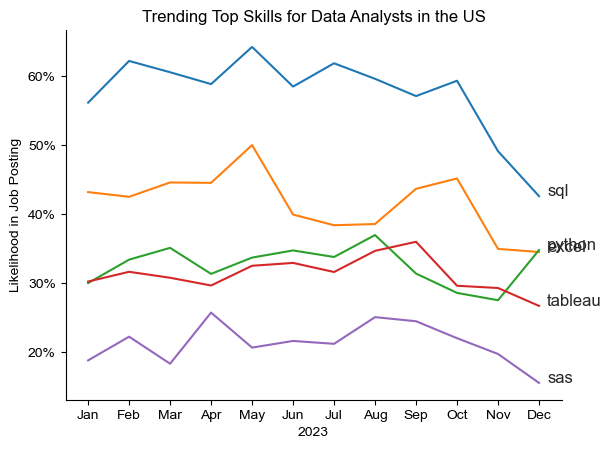

In [10]:
df_plot = df_DA_US_percent.iloc[:, :5]

sns.lineplot(data=df_plot, dashes=False, palette='tab10')
sns.set_theme(style='ticks')
sns.despine()

plt.title('Trending Top Skills for Data Analysts in the US')
plt.ylabel('Likelihood in Job Posting')
plt.xlabel('2023')
plt.legend().remove()

from matplotlib.ticker import PercentFormatter
ax = plt.gca()
ax.yaxis.set_major_formatter(PercentFormatter(decimals=0))

for i in range(5):
    plt.text(11.2, df_plot.iloc[-1, i], df_plot.columns[i])